In [1]:
import tensorflow as tf
# print(tf.__version__)

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import fbeta_score

from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

from sklearn.model_selection import StratifiedKFold

from imblearn.over_sampling import RandomOverSampler

import matplotlib.pyplot as plt
from visualisation import plot_cm
import joblib

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 13547782638732843379
xla_global_id: -1
]
Num GPUs Available:  0


In [2]:
SEED = 41

# Load Data

In [3]:
df = pd.read_csv("../../data/training_data.csv")

# Prep Data

In [4]:
train_df, test_df = train_test_split(df, test_size=0.2,stratify=df['type'],random_state=SEED) #

train_labels = np.array(train_df.pop('type'))
test_labels = np.array(test_df.pop('type'))



train_features = np.array(train_df[['-logP_Struc','-logP_Contact',"area_sc",'per_con','per_no_con','contact_order']])
test_features = np.array(test_df[['-logP_Struc','-logP_Contact',"area_sc",'per_con','per_no_con','contact_order']])


In [5]:
# scaler = RobustScaler()
scaler = joblib.load("./scaler.pkl")
train_features = scaler.transform(train_features)
test_features = scaler.transform(test_features)

## Cross Validation

In [6]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from joblib import dump, load

In [7]:
X,y = train_features, train_labels

In [8]:
# fix random seed for reproducibility
seed = SEED
np.random.seed(seed)


HISTORY_LIST = []

save_dir = './saved_models/'
fold_num = 0


BATCH_SIZE=1024
EPOCHS=200

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

train_fbeta = []
val_fbeta = []

for train_ix, val_ix in kfold.split(X, y):
    
    print(f"\n################################# Fold Number {fold_num}#################################")
   

    train_X, val_X = X[train_ix], X[val_ix]
    train_y, val_y = y[train_ix], y[val_ix]
    
    ros = RandomOverSampler(random_state=SEED)
    X_train_resampled, y_train_resampled = ros.fit_resample(train_X, train_y)
    
    model = RandomForestClassifier(random_state=seed)
    # model = svm.SVC(random_state=SEED)
    # model = LogisticRegression(random_state=seed)    
    

    val_ds = tf.data.Dataset.from_tensor_slices((val_X, val_y)).cache()
    resampled_ds = tf.data.Dataset.from_tensor_slices((X_train_resampled,y_train_resampled))
    
    history = model.fit(X_train_resampled, y_train_resampled)
    
    train_pred = model.predict_proba(X_train_resampled)[:,1]
    val_pred = model.predict_proba(val_X)[:,1]
    
    train_fbeta.append(fbeta_score(y_train_resampled, train_pred >= 0.5, beta=2))
    val_fbeta.append(fbeta_score(val_y, val_pred >= 0.5, beta=2))
   
    print(fbeta_score(val_y, val_pred >= 0.5, beta=2))
    # print(fbeta_score(val_y, val_pred >= 0.5, beta=2))
    dump(history, "./saved_models/model_RandomForest_"+str(fold_num)+".joblib")
    
    HISTORY_LIST.append(history)

    tf.keras.backend.clear_session()

    fold_num += 1
    

train_mean_mcc = np.mean(train_fbeta) .round(2)
val_mean_mcc = np.mean(val_fbeta).round(2)
train_std_mcc = np.std(train_fbeta).round(2)
val_std_mcc = np.std(val_fbeta).round(2)

print("\n================================= Final Results =================================")
print("RandomForest:")
print("fbeta_score:")
print(f"  Training Average ± Std Dev: {train_mean_mcc} ± {train_std_mcc}")
print(f"  Validation Average ± Std Dev: {val_mean_mcc} ± {val_std_mcc}")


################################# Fold Number 0#################################
0.6388888888888888

################################# Fold Number 1#################################
0.4594594594594595

################################# Fold Number 2#################################
0.6741573033707865

################################# Fold Number 3#################################
0.6145251396648045

################################# Fold Number 4#################################
0.44642857142857145

================================= Final Results =================================
RandomForest:
fbeta_score:
  Training Average ± Std Dev: 1.0 ± 0.0
  Validation Average ± Std Dev: 0.57 ± 0.09


[[1463    7]
 [  27   19]]
[[1460   10]
 [  24   22]]
[[1461    9]
 [  28   18]]
[[1461    9]
 [  31   15]]
[[1460   10]
 [  27   19]]


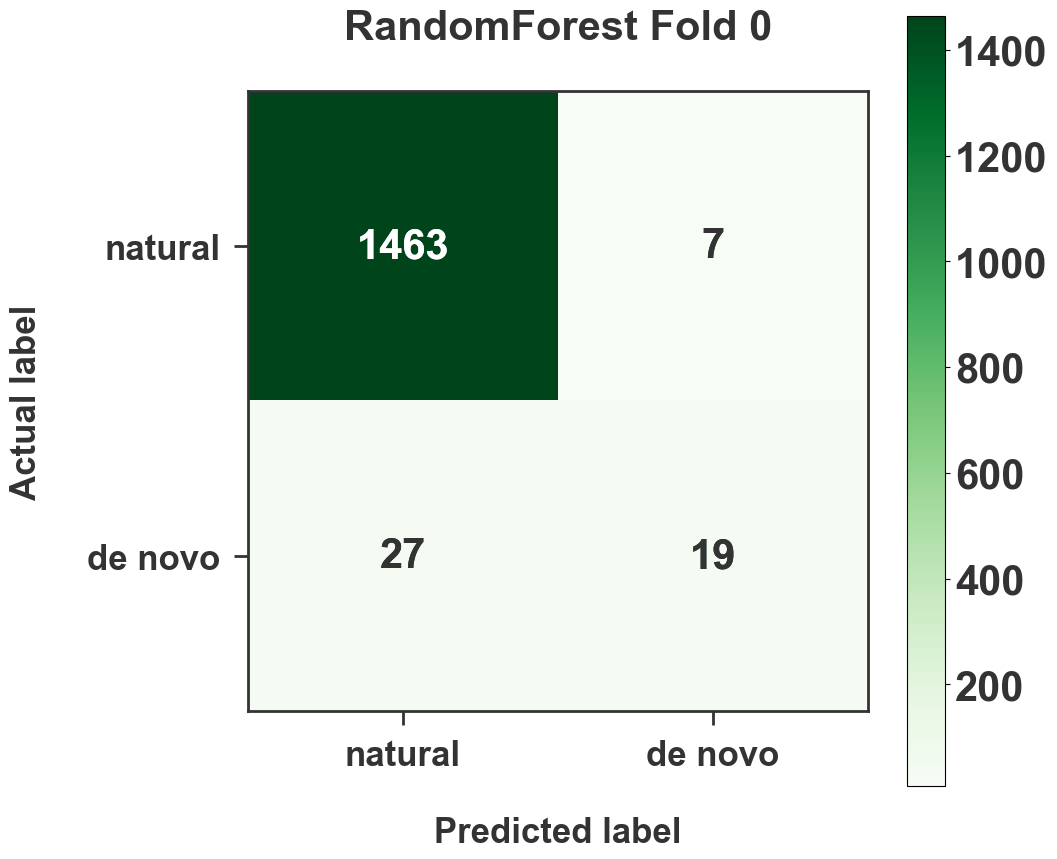

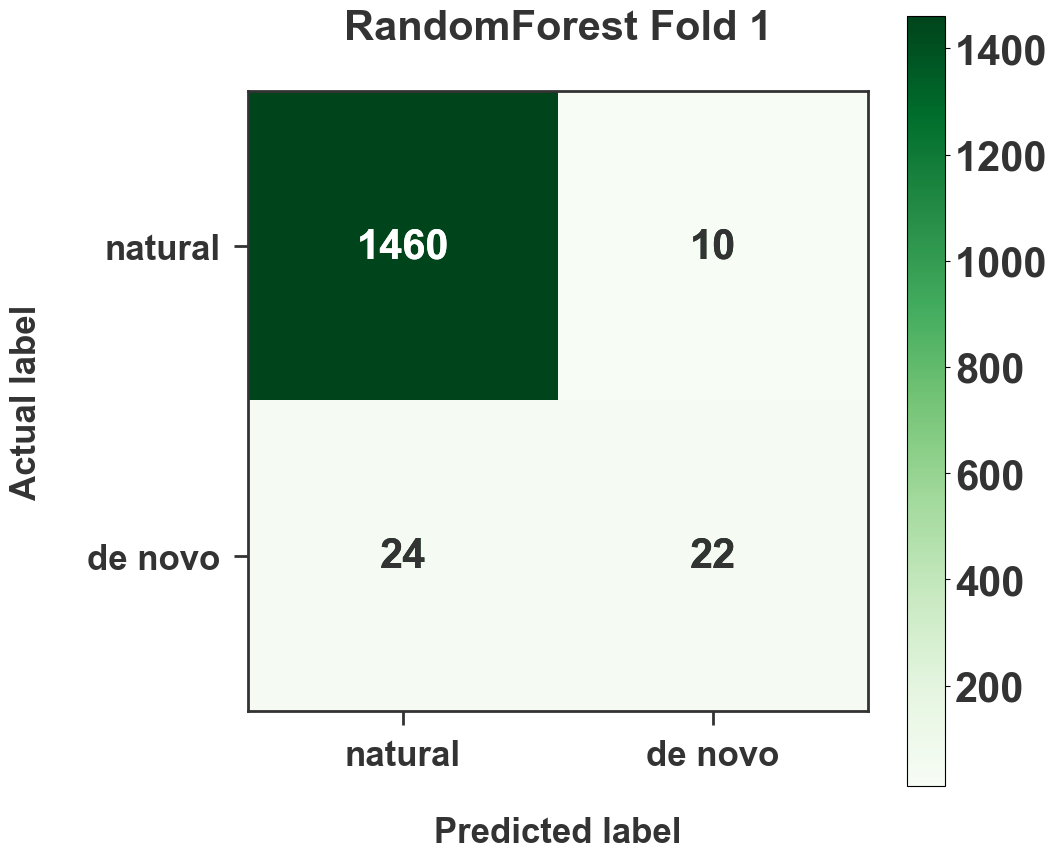

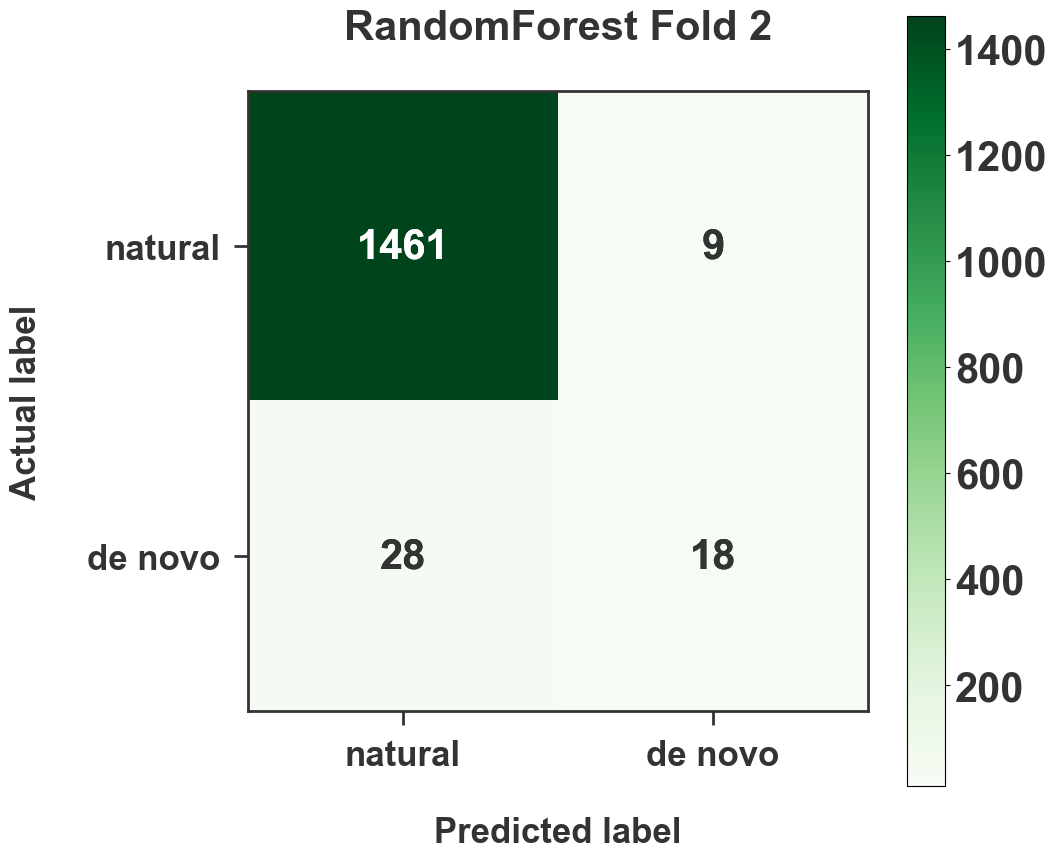

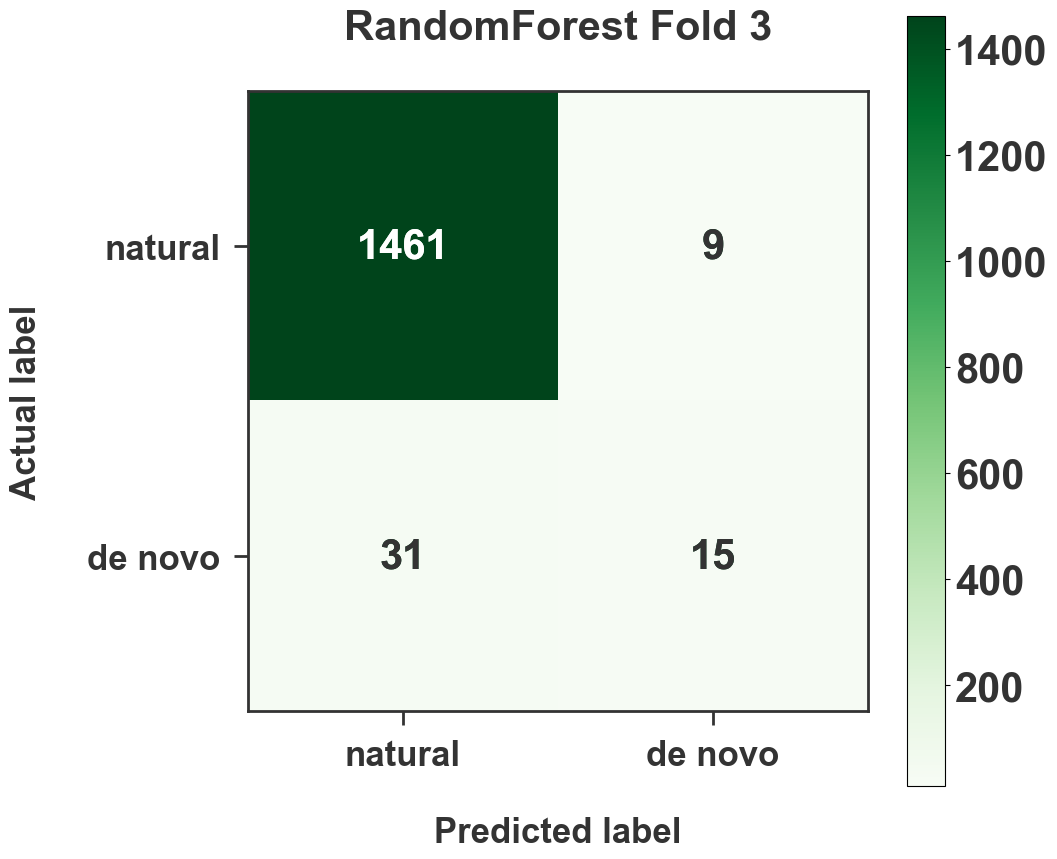

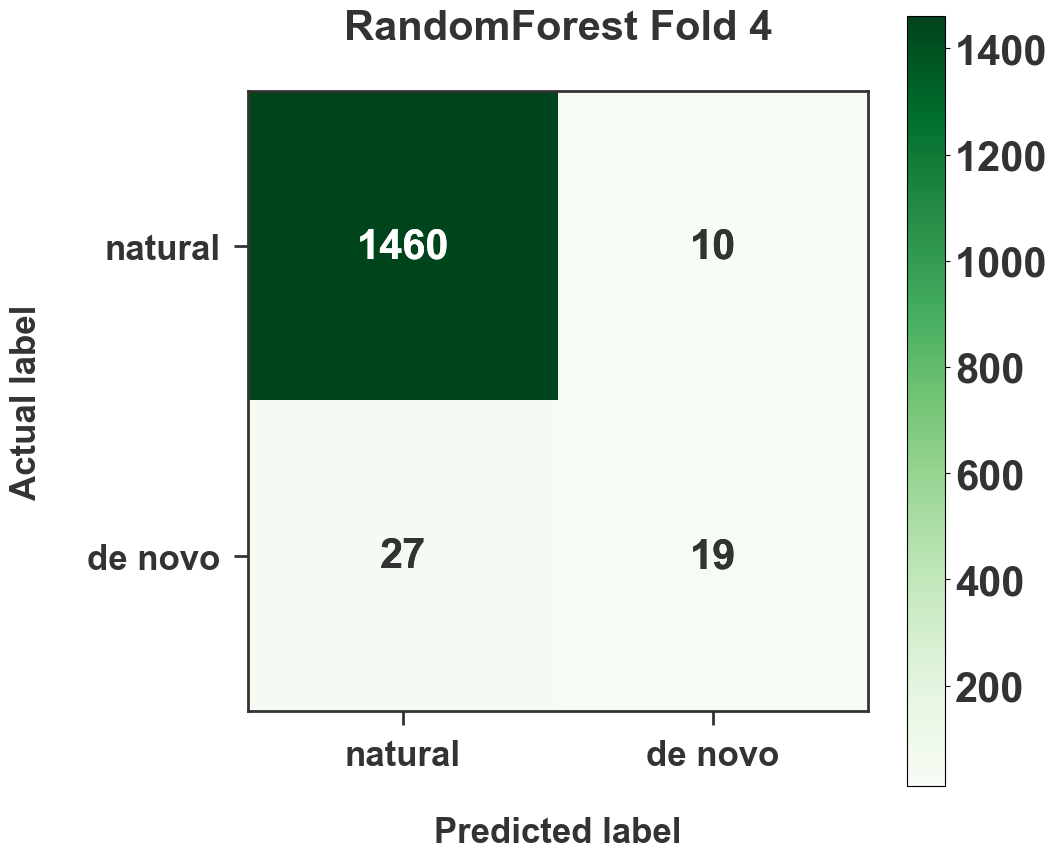

In [9]:
color = plt.cm.Greens

for i in range(0,fold_num):
    my_model = load("./saved_models/model_RandomForest_"+str(i)+".joblib")
    test_predictions = my_model.predict(test_features)
    plot_cm(test_labels, test_predictions,color,title=f"RandomForest Fold {i}\n",ylabel="Actual label\n",xlabel="\nPredicted label")
    plt.savefig("./cm/cm_RandomForest_"+str(i),dpi=300,bbox_inches='tight')

In [10]:
# fix random seed for reproducibility
seed = SEED
np.random.seed(seed)


HISTORY_LIST = []

save_dir = './saved_models/'
fold_num = 0


BATCH_SIZE=1024
EPOCHS=200

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

train_fbeta = []
val_fbeta = []

for train_ix, val_ix in kfold.split(X, y):
    
    print(f"\n################################# Fold Number {fold_num}#################################")
   

    train_X, val_X = X[train_ix], X[val_ix]
    train_y, val_y = y[train_ix], y[val_ix]
    
    ros = RandomOverSampler(random_state=SEED)
    X_train_resampled, y_train_resampled = ros.fit_resample(train_X, train_y)
    
    # model = RandomForestClassifier(random_state=seed)
    model = svm.SVC(random_state=SEED,probability=True)
    # model = LogisticRegression(random_state=seed)    
    

    val_ds = tf.data.Dataset.from_tensor_slices((val_X, val_y)).cache()
    resampled_ds = tf.data.Dataset.from_tensor_slices((X_train_resampled,y_train_resampled))
    
    history = model.fit(X_train_resampled, y_train_resampled)
    
    train_pred = model.predict_proba(X_train_resampled)[:,1]
    val_pred = model.predict_proba(val_X)[:,1]
    
    train_fbeta.append(fbeta_score(y_train_resampled, train_pred >= 0.5, beta=2))
    val_fbeta.append(fbeta_score(val_y, val_pred >= 0.5, beta=2))
   
    print(fbeta_score(val_y, val_pred >= 0.5, beta=2))
    # print(fbeta_score(val_y, val_pred >= 0.5))
    dump(history, "./saved_models/model_SVC_"+str(fold_num)+".joblib")
    
    HISTORY_LIST.append(history)

    tf.keras.backend.clear_session()

    fold_num += 1
    
train_mean_mcc = np.mean(train_fbeta) .round(2)
val_mean_mcc = np.mean(val_fbeta).round(2)
train_std_mcc = np.std(train_fbeta).round(2)
val_std_mcc = np.std(val_fbeta).round(2)


print("\n================================= Final Results =================================")
print("SVC:")
print("fbeta_score:")
print(f"  Training Average ± Std Dev: {train_mean_mcc} ± {train_std_mcc}")
print(f"  Validation Average ± Std Dev: {val_mean_mcc} ± {val_std_mcc}")



################################# Fold Number 0#################################
0.6595744680851063

################################# Fold Number 1#################################
0.64453125

################################# Fold Number 2#################################
0.6719367588932806

################################# Fold Number 3#################################
0.6395348837209303

################################# Fold Number 4#################################
0.6504065040650406

================================= Final Results =================================
SVC:
fbeta_score:
  Training Average ± Std Dev: 0.93 ± 0.01
  Validation Average ± Std Dev: 0.65 ± 0.01


[[1399   71]
 [   8   38]]
[[1385   85]
 [   8   38]]
[[1377   93]
 [   6   40]]
[[1375   95]
 [   6   40]]
[[1388   82]
 [   9   37]]


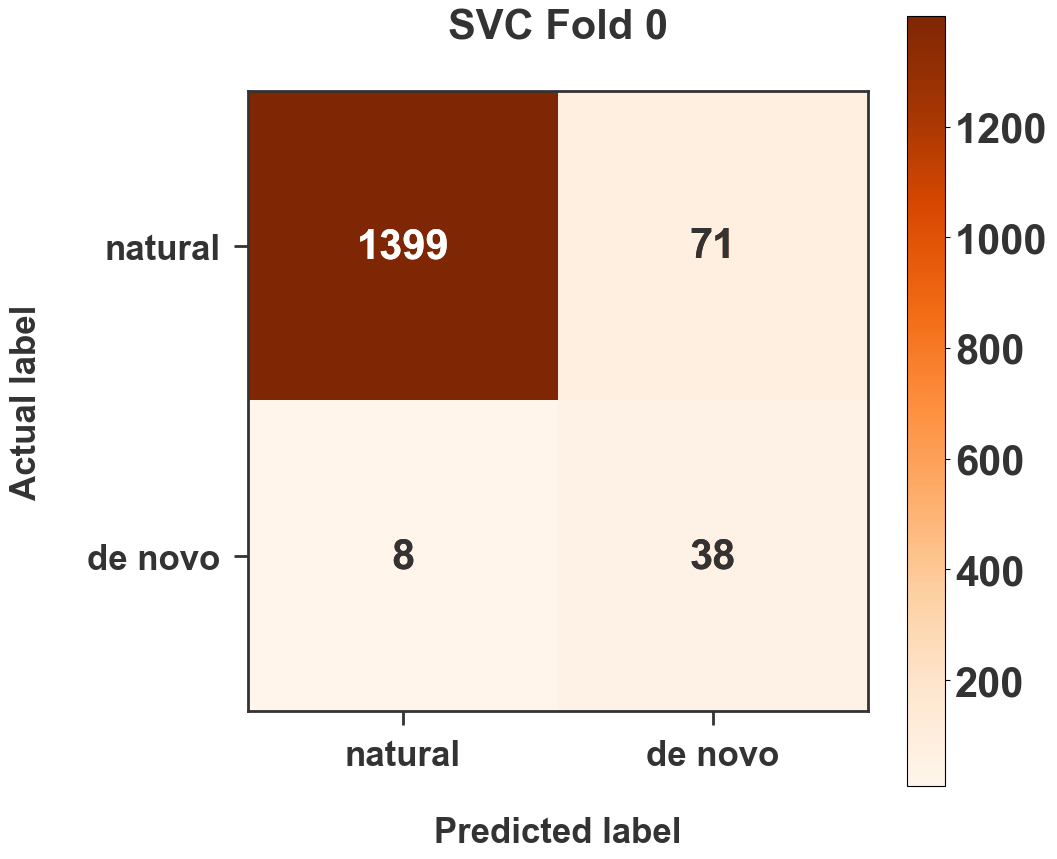

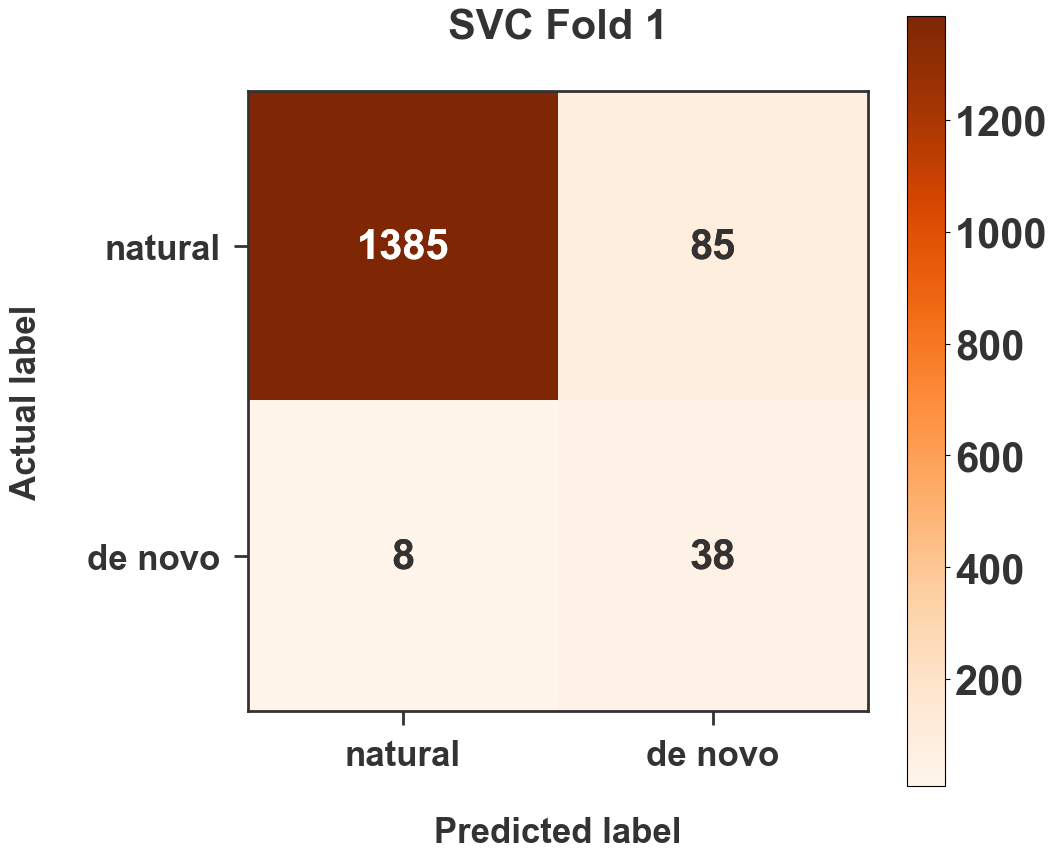

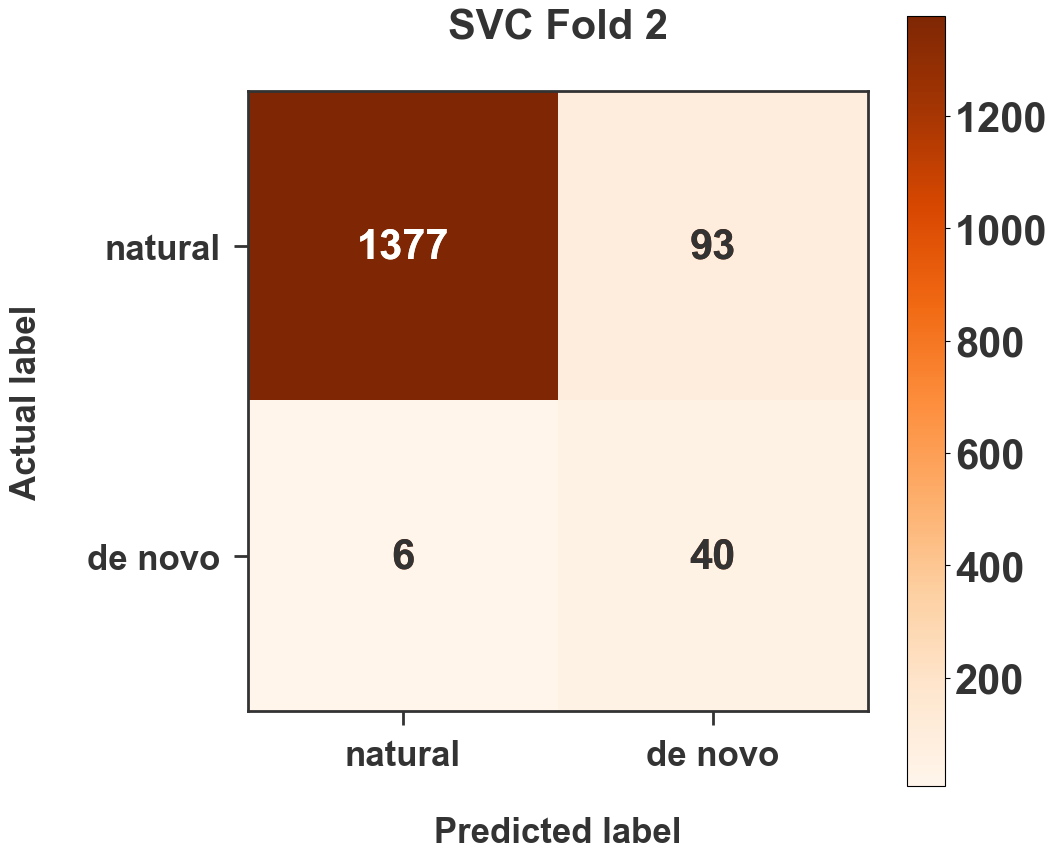

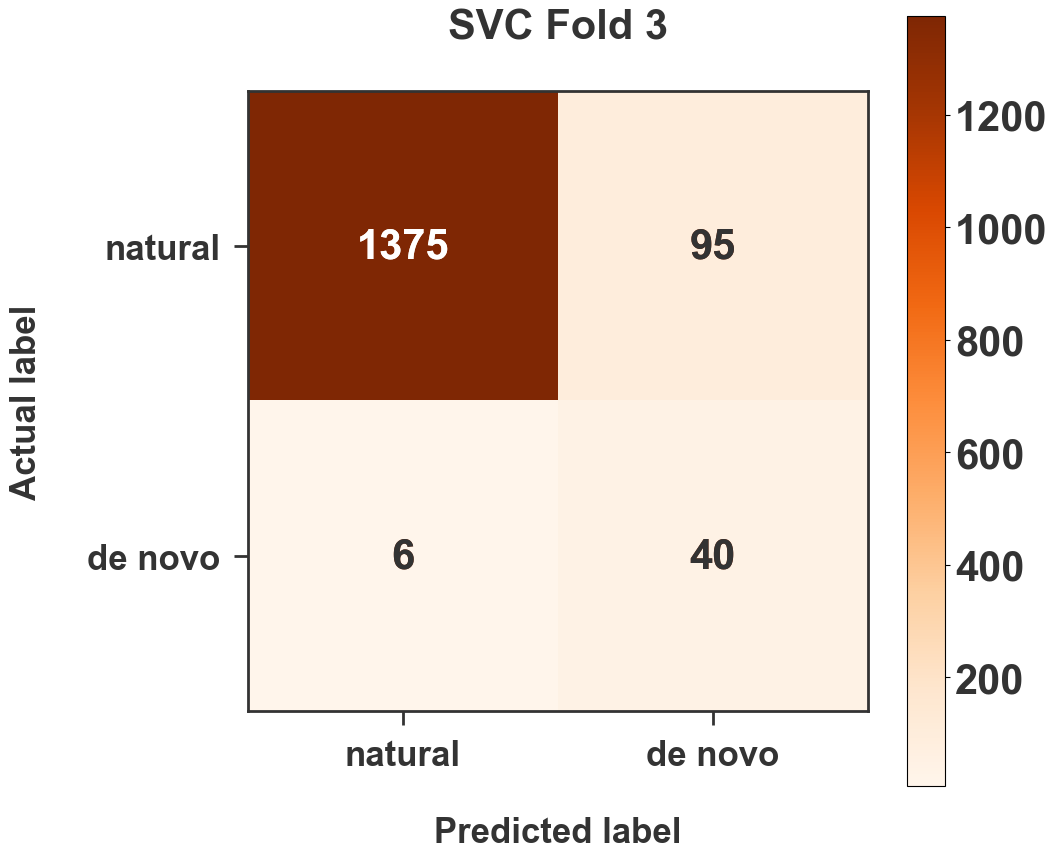

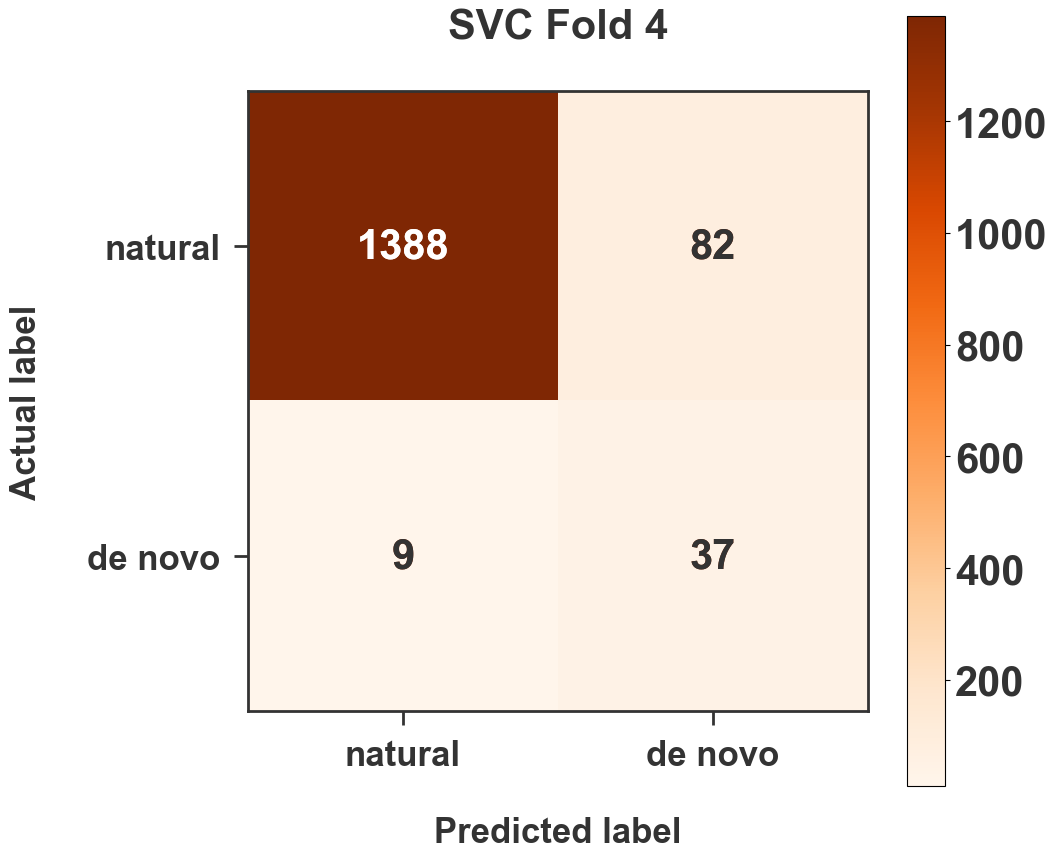

In [11]:
color = plt.cm.Oranges

for i in range(0,fold_num):
    my_model = load("./saved_models/model_SVC_"+str(i)+".joblib")
    test_predictions = my_model.predict(test_features)
    plot_cm(test_labels, test_predictions,color,title=f"SVC Fold {i}\n",ylabel="Actual label\n",xlabel="\nPredicted label")
    plt.savefig("./cm/cm_SVC_"+str(i),dpi=300,bbox_inches='tight')

In [12]:
# fix random seed for reproducibility
seed = SEED
np.random.seed(seed)


HISTORY_LIST = []

save_dir = './saved_models/'
fold_num = 0


BATCH_SIZE=1024
EPOCHS=200

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

train_fbeta = []
val_fbeta = []

for train_ix, val_ix in kfold.split(X, y):
    
    print(f"\n################################# Fold Number {fold_num}#################################")
   

    train_X, val_X = X[train_ix], X[val_ix]
    train_y, val_y = y[train_ix], y[val_ix]
    
    ros = RandomOverSampler(random_state=SEED)
    X_train_resampled, y_train_resampled = ros.fit_resample(train_X, train_y)
    
    # model = RandomForestClassifier(random_state=seed)
    # model = svm.SVC(random_state=SEED)
    model = LogisticRegression(random_state=seed)    
    

    val_ds = tf.data.Dataset.from_tensor_slices((val_X, val_y)).cache()
    resampled_ds = tf.data.Dataset.from_tensor_slices((X_train_resampled,y_train_resampled))
    
    history = model.fit(X_train_resampled, y_train_resampled)
    
    train_pred = model.predict_proba(X_train_resampled)[:,1]
    val_pred = model.predict_proba(val_X)[:,1]
    
    train_fbeta.append(fbeta_score(y_train_resampled, train_pred >= 0.5, beta=2))
    val_fbeta.append(fbeta_score(val_y, val_pred >= 0.5, beta=2))
   
    print(fbeta_score(val_y, val_pred >= 0.5, beta=2))
    # print(fbeta_score(val_y, val_pred >= 0.5))
    dump(history, "./saved_models/model_LogisticRegression_"+str(fold_num)+".joblib")
    
    HISTORY_LIST.append(history)

    tf.keras.backend.clear_session()

    fold_num += 1
    
train_mean_mcc = np.mean(train_fbeta) .round(2)
val_mean_mcc = np.mean(val_fbeta).round(2)
train_std_mcc = np.std(train_fbeta).round(2)
val_std_mcc = np.std(val_fbeta).round(2)


print("\n================================= Final Results =================================")
print("LogisticRegression:")
print("fbeta_score")
print(f"  Training Average ± Std Dev: {train_mean_mcc} ± {train_std_mcc}")
print(f"  Validation Average ± Std Dev: {val_mean_mcc} ± {val_std_mcc}")




################################# Fold Number 0#################################
0.54421768707483

################################# Fold Number 1#################################
0.5016181229773463

################################# Fold Number 2#################################
0.5466237942122186

################################# Fold Number 3#################################
0.5481727574750831

################################# Fold Number 4#################################
0.5463576158940397

================================= Final Results =================================
LogisticRegression:
fbeta_score
  Training Average ± Std Dev: 0.9 ± 0.01
  Validation Average ± Std Dev: 0.54 ± 0.02


[[1323  147]
 [   8   38]]
[[1328  142]
 [   9   37]]
[[1315  155]
 [   8   38]]
[[1307  163]
 [   7   39]]
[[1312  158]
 [   8   38]]


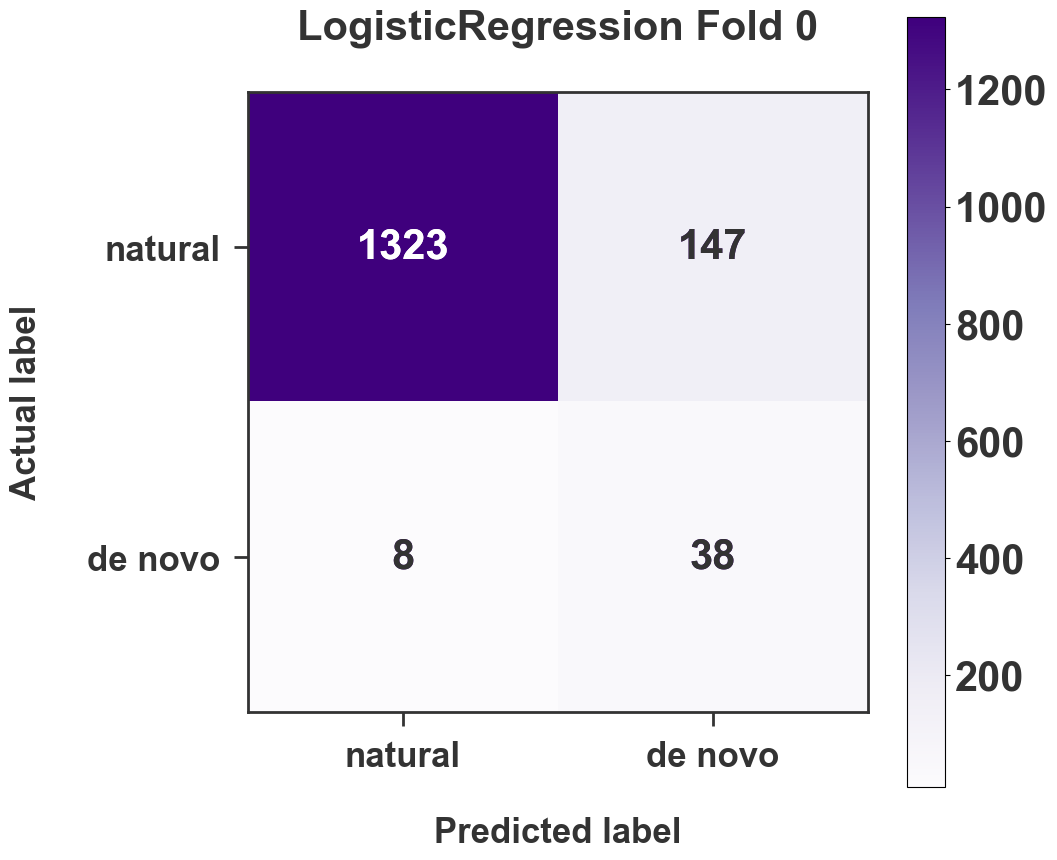

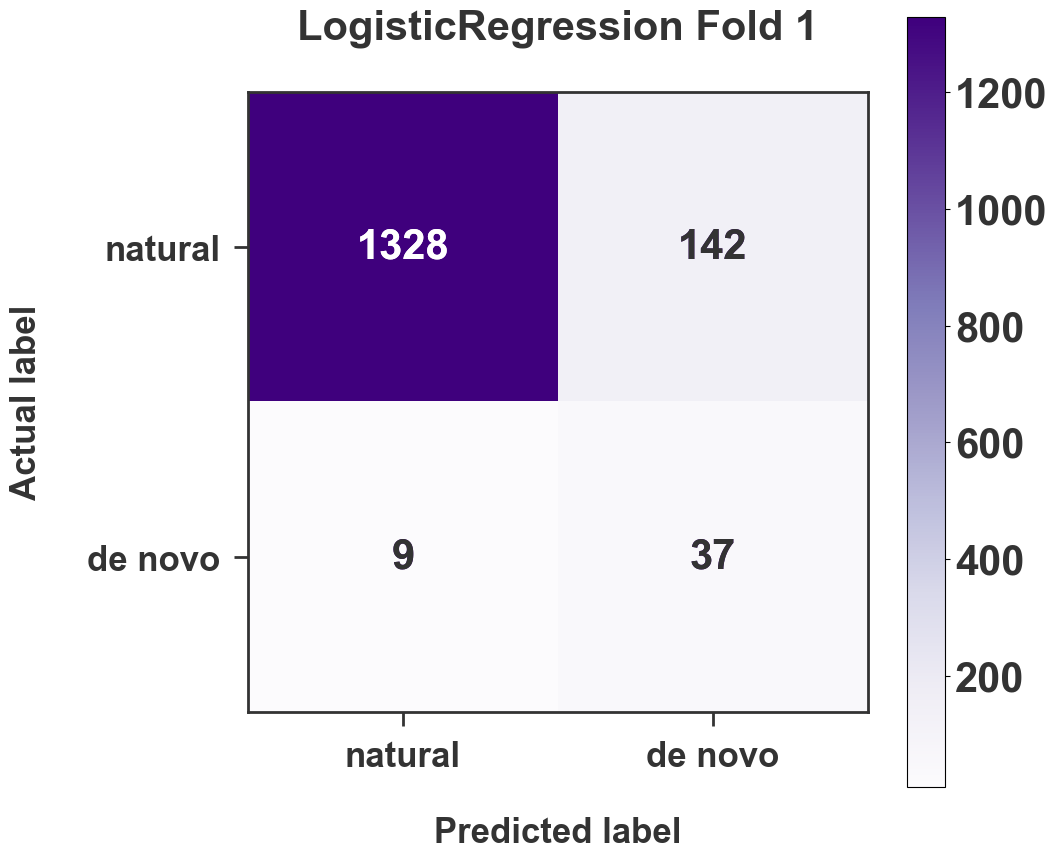

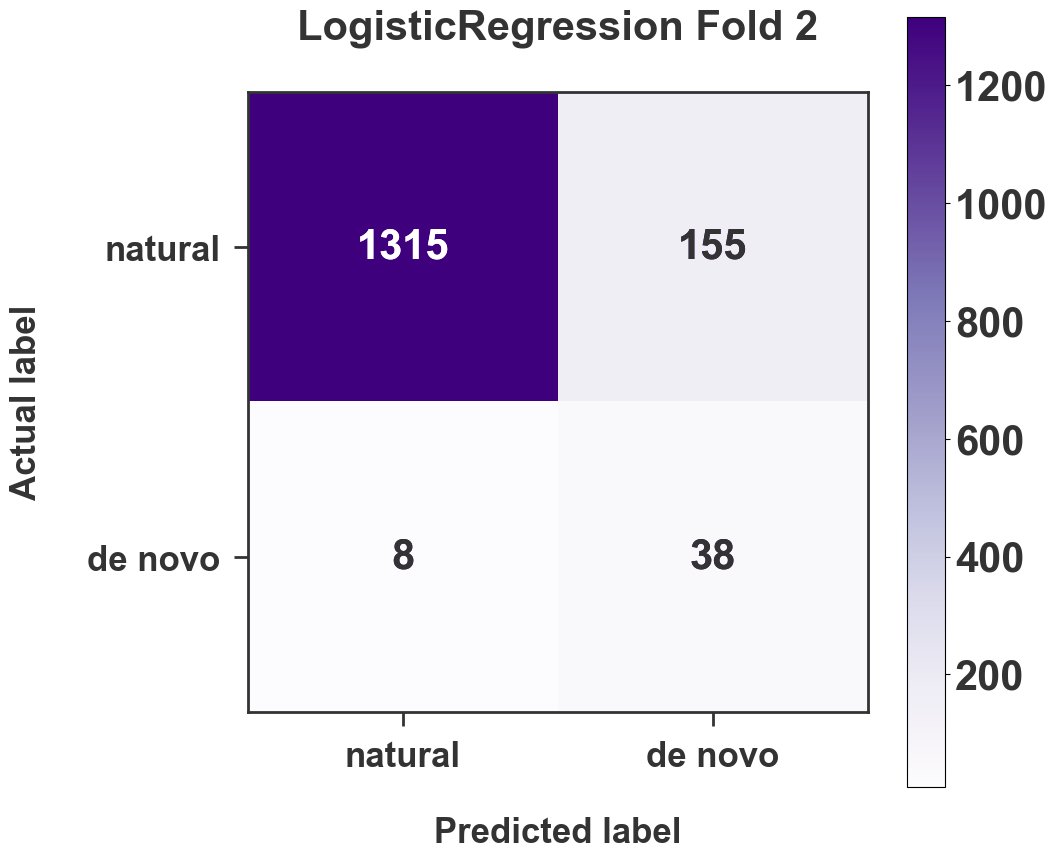

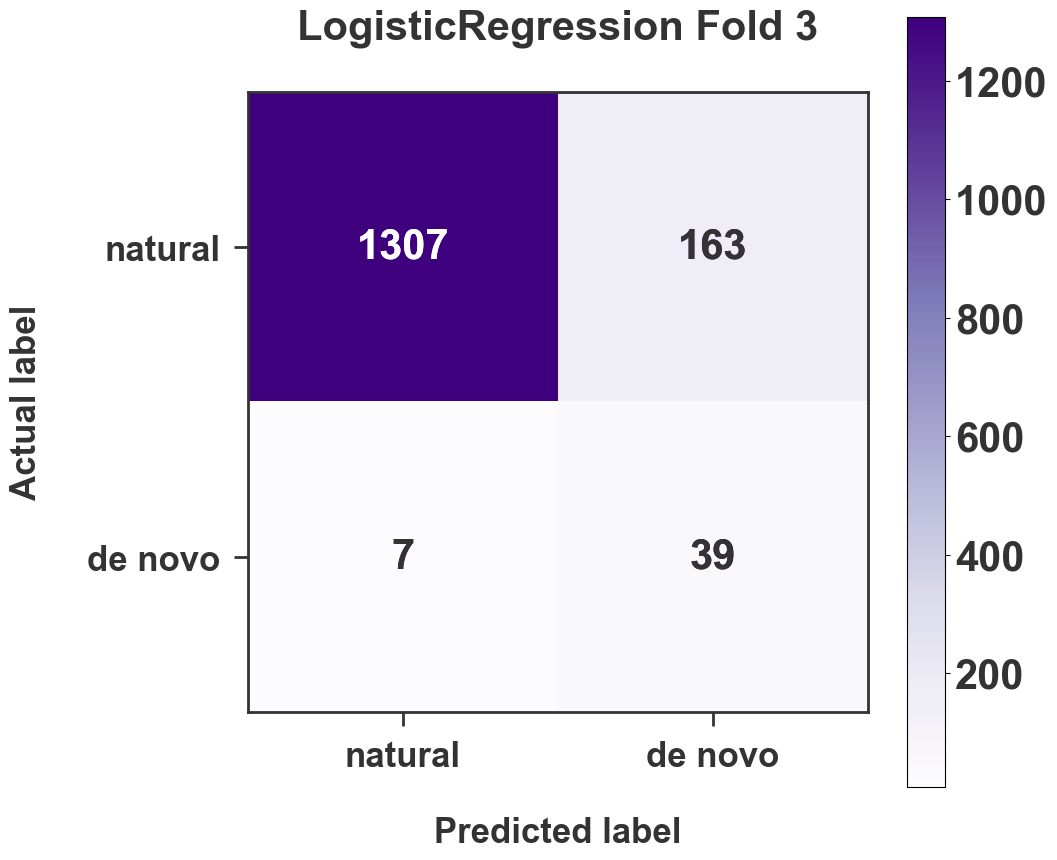

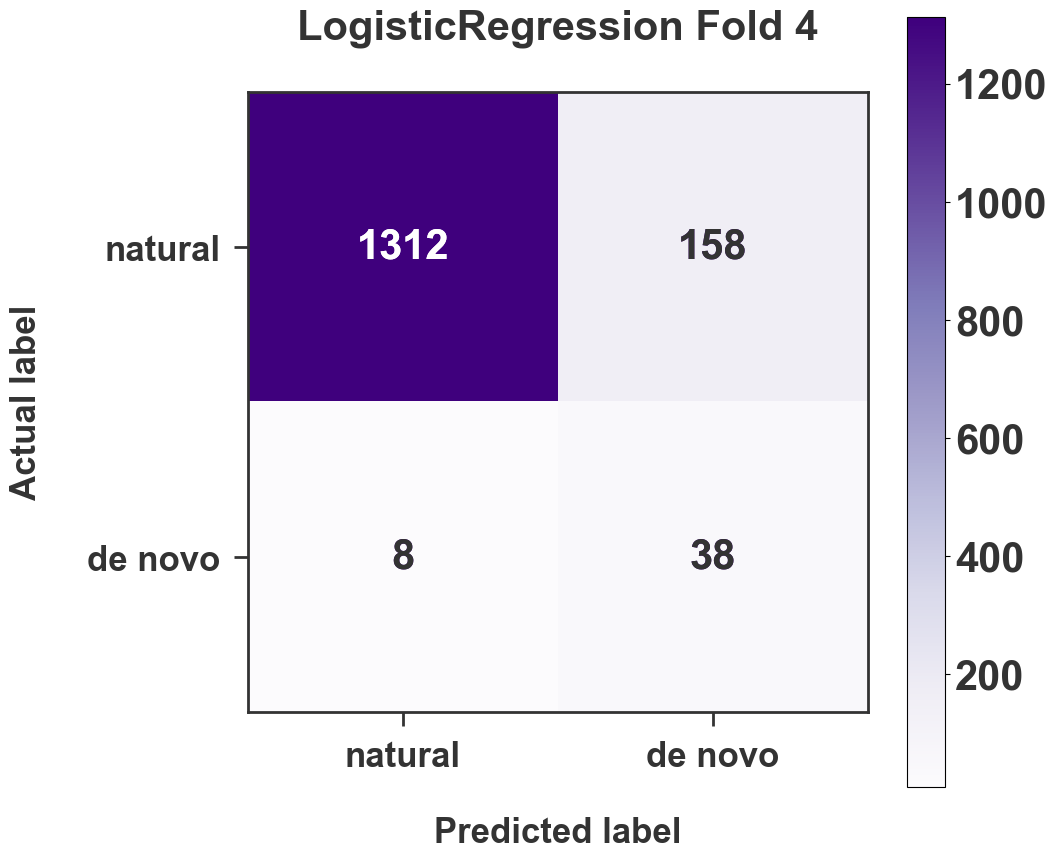

In [13]:
color = plt.cm.Purples

for i in range(0,fold_num):
    my_model = load("./saved_models/model_LogisticRegression_"+str(i)+".joblib")
    test_predictions = my_model.predict(test_features)
    plot_cm(test_labels, test_predictions,color,title=f"LogisticRegression Fold {i}\n",ylabel="Actual label\n",xlabel="\nPredicted label")
    plt.savefig("./cm/cm_LogisticRegression_"+str(i),dpi=300,bbox_inches='tight')